In [9]:
import pandas as pd

results = pd.read_csv("metrics_results/bus_ontime_results.csv")

for rt in ["60", "77"]:
    print(f"\n{'='*60}")
    print(f"  ROUTE {rt}")
    print(f"{'='*60}")
    
    df = results[results["rt"] == rt].copy()
    print(f"Total observations: {len(df)}")
    print(f"Status breakdown:\n{df['on_time_status'].value_counts().to_string()}")
    print()
    
    # Where dly disagrees with us
    df["dly_says_late"] = df["dly"].astype(bool)
    df["we_say_late"] = df["on_time_status"] == "late"
    disagree = df[df["dly_says_late"] != df["we_say_late"]]
    print(f"Disagreements with dly ({len(disagree)} rows):")
    print(disagree[["vid","tmstmp","pdist","delay_minutes","on_time_status",
                     "dly","matched_trip_id","prev_stop_name","next_stop_name",
                     "time_match_score_minutes"]].to_string())
    print()

    # Full picture of all vehicles on these routes
    print("All observations:")
    print(df[["vid","tmstmp","pdist","delay_minutes","on_time_status",
              "dly","time_match_score_minutes","prev_stop_name","next_stop_name"]
             ].sort_values(["vid","tmstmp"]).to_string())


  ROUTE 60
Total observations: 10
Status breakdown:
on_time_status
on_time    7
early      3

Disagreements with dly (2 rows):
      vid               tmstmp  pdist  delay_minutes on_time_status   dly  matched_trip_id        prev_stop_name          next_stop_name  time_match_score_minutes
331  8279  2026-02-19 23:38:00  49661           -1.6          early  True    6770005108020  79th Street & Hamlin  79th Street & Lawndale                      0.05
332  8279  2026-02-19 23:40:00  49661            1.6        on_time  True    6770002395070   79th Street & Tripp   79th Street & Kostner                      1.11

All observations:
      vid               tmstmp  pdist  delay_minutes on_time_status    dly  time_match_score_minutes            prev_stop_name                               next_stop_name
331  8279  2026-02-19 23:38:00  49661           -1.6          early   True                      0.05      79th Street & Hamlin                       79th Street & Lawndale
332  8279  2026-02-1

In [4]:
import pandas as pd

trips    = pd.read_csv("Datasets/trips.txt",    dtype=str)
vehicles = pd.read_csv("data/test3/bus_data_current_chicago.csv", dtype=str)

# Look at tatripid values from vehicles
print("Sample tatripid values from API:")
print(vehicles["pid"].dropna().unique().tolist())
print()

# Look at shape_id values from trips
print("Sample shape_ids from trips:")
print(trips["shape_id"].unique().tolist())
print()

# Try to find the suffix match pattern
# If tatripid = "7873", shape_id = "67707873" → suffix of len 4
# Try different suffix lengths
sample_tatripids = vehicles["pid"].dropna().unique().tolist()
for tid in sample_tatripids:
    tid = str(tid).strip()
    matches = trips[trips["shape_id"].str.endswith(tid)]
    print(f"pid={tid} → {len(matches)} shape_id matches")
    if len(matches):
        print(f"  matched shape_ids: {matches['shape_id'].unique().tolist()}")
        print(f"  matched routes:    {matches['route_id'].unique().tolist()}")
print()

# Also check calendar join
calendar = pd.read_csv("Datasets/calendar.txt", dtype=str)
print(f"calendar rows: {len(calendar)}, service_ids: {calendar['service_id'].nunique()}")
print(f"trips with service_id: {trips['service_id'].nunique()} unique service_ids")

# Confirm trips → calendar join works
merged = trips.merge(calendar, on="service_id", how="left")
print(f"trips with calendar join: {merged['monday'].notna().sum()} / {len(trips)}")

Sample tatripid values from API:
['18414', '18415', '19378', '25899', '28327', '7107', '14134', '9368', '9376', '7128', '7129', '593', '9372', '25896', '4135', '7471', '4275', '4287', '4288', '954', '959', '4557', '14113', '3932', '3936', '2156', '10941', '1039', '1042', '10916', '10934', '7100', '7101', '5905', '5906', '6126', '6128', '1178', '1180', '4107', '4108', '1192', '4718', '14120', '28346', '28350', '28351', '4573', '28357', '4588', '4590', '1277', '1286', '5424', '5425', '20424', '1345', '1350', '7110', '7111', '7120', '10917', '10930', '6657', '6662', '6665', '6982', '4605', '4610', '1500', '2291', '7029', '7032', '95', '10913', '8420', '8421', '8422', '29251', '4618', '4621', '10902', '10944', '1598', '1599', '1612', '1628', '3501', '19369', '1031', '3090', '10909', '16550', '16551', '1656', '15953', '7570', '10943', '5569', '5570', '5571', '2944', '14118', '14119', '8143', '8146', '8147', '10956', '29260', '754', '757', '10911', '10912', '6582', '4524', '6414', '8102', '9

In [10]:
import pandas as pd

vehicles = pd.read_csv("Datasets/api_mar1.csv", dtype=str, nrows=5000)
trips    = pd.read_csv("Datasets/trips.txt", dtype=str)

print("Vehicle columns:", vehicles.columns.tolist())
print()
print("Sample pid values:", vehicles["pid"].dropna().unique()[:10].tolist())
print()

# Confirm the join: shape_id = "677" + pid.zfill(5)
sample_pids = vehicles["pid"].dropna().unique()[:5]
for pid in sample_pids:
    expected_shape = "677" + str(pid).zfill(5)
    match = trips[trips["shape_id"] == expected_shape]
    print(f"pid={pid} → shape_id={expected_shape} → {len(match)} trips → routes: {match['route_id'].unique().tolist()}")

Vehicle columns: ['vid', 'tmstmp', 'lat', 'lon', 'hdg', 'pid', 'rt', 'des', 'pdist', 'dly', 'tatripid', 'origtatripno', 'tablockid', 'zone', 'mode', 'psgld', 'stst', 'stsd', 'pulled_at', 'rt_chunk']

Sample pid values: ['6351', '8085', '5528', '5531', '18414', '18415', '19378', '19379', '19374', '7107']

pid=6351 → shape_id=67706351 → 28 trips → routes: ['1']
pid=8085 → shape_id=67708085 → 31 trips → routes: ['1']
pid=5528 → shape_id=67705528 → 19 trips → routes: ['2']
pid=5531 → shape_id=67705531 → 12 trips → routes: ['2']
pid=18414 → shape_id=67718414 → 280 trips → routes: ['3']


In [11]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   vid           5000 non-null   object
 1   tmstmp        5000 non-null   object
 2   lat           5000 non-null   object
 3   lon           5000 non-null   object
 4   hdg           5000 non-null   object
 5   pid           5000 non-null   object
 6   rt            5000 non-null   object
 7   des           5000 non-null   object
 8   pdist         5000 non-null   object
 9   dly           5000 non-null   object
 10  tatripid      5000 non-null   object
 11  origtatripno  5000 non-null   object
 12  tablockid     5000 non-null   object
 13  zone          0 non-null      object
 14  mode          5000 non-null   object
 15  psgld         0 non-null      object
 16  stst          5000 non-null   object
 17  stsd          5000 non-null   object
 18  pulled_at     5000 non-null   object
 19  rt_chu

In [10]:
import pandas as pd

vehicles = pd.read_csv("data/bus_data_current_chicago.csv")
vehicles["tmstmp"] = pd.to_datetime(vehicles["tmstmp"])
vehicles = vehicles[vehicles["vid"].astype(str) == "8279"].sort_values("tmstmp")
print(vehicles[["vid","tmstmp","pdist","rt"]].to_string())
print()
print("pdist delta:", vehicles["pdist"].diff().abs().values)
print("time delta (min):", vehicles["tmstmp"].diff().dt.total_seconds().div(60).values)

      vid              tmstmp  pdist  rt
250  8279 2026-02-19 23:38:00  49661  60
538  8279 2026-02-19 23:40:00  49661  60

pdist delta: [nan  0.]
time delta (min): [nan  2.]


In [11]:
import pandas as pd

vehicles["tmstmp"] = pd.to_datetime(vehicles["tmstmp"])

print("vid dtype before cleaning:", vehicles["vid"].dtype)
print("sample vids:", vehicles["vid"].head(5).tolist())

# Simulate exactly what detect_ghost_buses does
vehicles["vid"] = vehicles["vid"].astype(str)
vehicles = vehicles.sort_values(["vid", "tmstmp"])

g = vehicles.groupby("vid")
vehicles["_prev_pdist"] = g["pdist"].shift(1)
vehicles["_prev_tmstmp"] = g["tmstmp"].shift(1)
vehicles["_pdist_delta"] = (vehicles["pdist"] - vehicles["_prev_pdist"]).abs()
vehicles["_time_delta_min"] = (vehicles["tmstmp"] - vehicles["_prev_tmstmp"]).dt.total_seconds() / 60

# Check specifically for vid 8279
v = vehicles[vehicles["vid"] == "8279"]
print()
print("vid 8279 ghost signals:")
print(v[["vid","tmstmp","pdist","_prev_pdist","_pdist_delta","_time_delta_min"]].to_string())
print()

# Check the ghost conditions
v = v.copy()
v["ghost_frozen"] = (
    (v["_pdist_delta"] < 50) &
    (v["_time_delta_min"] > 1) &
    v["_prev_pdist"].notna()
)
print("ghost_frozen:", v["ghost_frozen"].tolist())
print("ghost_score:", (v["ghost_frozen"].astype(int) + 
                       ((v["_pdist_delta"] > 5280) & v["_prev_pdist"].notna()).astype(int)).tolist())

vid dtype before cleaning: int64
sample vids: [8279, 8279]

vid 8279 ghost signals:
      vid              tmstmp  pdist  _prev_pdist  _pdist_delta  _time_delta_min
250  8279 2026-02-19 23:38:00  49661          NaN           NaN              NaN
538  8279 2026-02-19 23:40:00  49661      49661.0           0.0              2.0

ghost_frozen: [False, True]
ghost_score: [0, 1]


In [13]:
import pandas as pd

results = pd.read_csv("bus_ontime_results.csv", low_memory=False)

rt19 = results[results["rt"] == "19"].copy()
rt19["dly_says_late"] = rt19["dly"].astype(bool)
rt19["we_say_late"]   = rt19["on_time_status"] == "late"
rt19["agree"]         = rt19["dly_says_late"] == rt19["we_say_late"]

print(f"Route 19 total observations: {len(rt19)}")
print(f"Status breakdown:\n{rt19['on_time_status'].value_counts().to_string()}")
print()
print(f"dly breakdown:\n{rt19['dly'].value_counts().to_string()}")
print()

# Focus on disagreements
disagree = rt19[~rt19["agree"]]
print(f"Disagreements: {len(disagree)}")
print()
print("Disagreement breakdown (dly vs our status):")
print(disagree.groupby(["dly", "on_time_status"]).size().to_string())
print()
print("Sample disagreements:")
print(disagree[["vid","tmstmp","pdist","delay_minutes","on_time_status",
                "dly","matched_trip_id","time_match_score_minutes",
                "prev_stop_name","next_stop_name"]].head(20).to_string())

Route 19 total observations: 1877
Status breakdown:
on_time_status
on_time      1533
early         322
late           12
unmatched       6
ghost           4

dly breakdown:
dly
False    940
True     937

Disagreements: 939

Disagreement breakdown (dly vs our status):
dly    on_time_status
False  late                7
True   early             151
       on_time           780
       unmatched           1

Sample disagreements:
          vid               tmstmp  pdist  delay_minutes on_time_status   dly  matched_trip_id  time_match_score_minutes                      prev_stop_name             next_stop_name
1522633  4012  2026-02-24 21:35:00    748           -2.4          early  True     6.770049e+12                      2.37                  Archer & St. Louis             Archer & Homan
1522634  4012  2026-02-24 21:37:00    748            0.1        on_time  True     6.770031e+12                      0.12  Archer & Pope John Paul II/43rd St            Archer & Kedzie
1522635  4012  2026

In [14]:
import pandas as pd

results = pd.read_csv("bus_ontime_results.csv", low_memory=False)

# Check jump distribution — are these concentrated on specific vehicles/routes?
jumps = results[results["ghost_jump"] == True]
print(f"Total jump observations: {len(jumps)}")
print(f"Unique vehicles with jumps: {jumps['vid'].nunique()}")
print()
print("Jumps by route (top 15):")
print(jumps.groupby("rt").size().sort_values(ascending=False).head(15).to_string())
print()
print("Vehicles with most jumps:")
print(jumps.groupby("vid").size().sort_values(ascending=False).head(15).to_string())
print()

# For route 169 specifically
rt169 = results[results["rt"] == "169"].copy()
rt169["dly_says_late"] = rt169["dly"].astype(bool)
rt169["we_say_late"] = rt169["on_time_status"] == "late"
rt169["agree"] = rt169["dly_says_late"] == rt169["we_say_late"]

print(f"\nRoute 169 — {len(rt169)} observations")
print(f"Status: {rt169['on_time_status'].value_counts().to_string()}")
print(f"\ndly breakdown: {rt169['dly'].value_counts().to_string()}")
print(f"\nDisagreement breakdown:")
disagree = rt169[~rt169["agree"]]
print(disagree.groupby(["dly", "on_time_status"]).size().to_string())
print()
print("Sample disagreements:")
print(disagree[["vid","tmstmp","pdist","delay_minutes","on_time_status",
                "dly","time_match_score_minutes","pdist_unreliable",
                "prev_stop_name","next_stop_name"]].head(15).to_string())

Total jump observations: 29746
Unique vehicles with jumps: 1598

Jumps by route (top 15):
rt
J14    6014
147    4778
6      3857
146    2053
47     1977
67     1515
26     1381
28      841
2       748
44      384
148     260
54      252
9       243
136     221
135     216

Vehicles with most jumps:
vid
4324    294
4331    271
4326    264
4011    258
4043    236
4068    235
4083    234
4176    232
4332    232
4070    221
4184    219
4309    208
4304    205
4053    205
4321    204


Route 169 — 1659 observations
Status: on_time_status
on_time    934
late       477
early      247
ghost        1

dly breakdown: dly
False    1643
True       16

Disagreement breakdown:
dly    on_time_status
False  late              466
True   early               1
       on_time             4

Sample disagreements:
          vid               tmstmp  pdist  delay_minutes on_time_status    dly  time_match_score_minutes  pdist_unreliable                  prev_stop_name           next_stop_name
1593704  4074  2

In [15]:
import pandas as pd

trips = pd.read_csv("Datasets/trips.txt", dtype=str)
rt169 = trips[trips["route_id"] == "169"]
print(f"Route 169 trips: {len(rt169)}")
print(f"Direction values: {rt169['direction_id'].value_counts().to_string()}")
print(f"Direction (text): {rt169['direction'].value_counts().to_string()}")
print()

# Also check if pdist values on route 169 are consistent
results = pd.read_csv("bus_ontime_results.csv", low_memory=False)
r169 = results[results["rt"] == "169"]
print(f"pdist range on route 169: {r169['pdist'].min()} - {r169['pdist'].max()}")
print(f"pdist std: {r169['pdist'].std():.0f}")
print(f"Unique vehicles: {r169['vid'].nunique()}")
print()

# Sample a vehicle and show its full pdist trajectory
sample_vid = r169["vid"].value_counts().index[0]
v = r169[r169["vid"] == sample_vid].sort_values("tmstmp")
print(f"Sample vehicle {sample_vid} on route 169:")
print(v[["tmstmp","pdist","delay_minutes","on_time_status","dly",
         "time_match_score_minutes"]].head(20).to_string())

Route 169 trips: 11
Direction values: direction_id
0    6
1    5
Direction (text): direction
West    6
East    5

pdist range on route 169: 0 - 88677
pdist std: 26588
Unique vehicles: 17

Sample vehicle 4332 on route 169:
                      tmstmp  pdist  delay_minutes on_time_status    dly  time_match_score_minutes
1758406  2026-02-20 20:51:00      0           -2.0          early  False                      2.00
1758407  2026-02-20 20:52:00      0           -1.0        on_time  False                      1.00
1758408  2026-02-20 20:54:00    525            0.6        on_time  False                      0.62
1758409  2026-02-20 20:55:00    759            1.4        on_time  False                      1.45
1758410  2026-02-20 20:57:00   1558            2.9        on_time  False                      2.86
1758411  2026-02-20 21:00:00   5718            2.7        on_time  False                      2.69
1758412  2026-02-20 21:02:00   7852            3.0        on_time  False             

In [16]:
import pandas as pd

# trips  = pd.read_csv("trips.txt", dtype=str)
st     = pd.read_parquet("gtfs_cache/stop_times_enriched.parquet")
results = pd.read_csv("bus_ontime_results.csv", low_memory=False)

# What times does route 169 actually operate according to GTFS?
rt169_trips = trips[trips["route_id"] == "169"]["trip_id"].tolist()
rt169_st    = st[st["trip_id"].isin(rt169_trips)]

print("Route 169 scheduled time windows:")
trip_windows = (
    rt169_st.groupby("trip_id")["arrival_minutes"]
    .agg(["min", "max"])
    .assign(
        start_time=lambda d: d["min"].apply(lambda m: f"{int(m//60):02d}:{int(m%60):02d}"),
        end_time  =lambda d: d["max"].apply(lambda m: f"{int(m//60):02d}:{int(m%60):02d}"),
    )
    .merge(trips[["trip_id","direction"]], on="trip_id")
    .sort_values("min")
)
print(trip_windows[["trip_id","direction","start_time","end_time"]].to_string())
print()

# What times are route 169 vehicles actually observed?
r169_results = results[results["rt"] == "169"].copy()
r169_results["tmstmp"] = pd.to_datetime(r169_results["tmstmp"])
r169_results["hour"]   = r169_results["tmstmp"].dt.hour

print("Route 169 vehicle observations by hour:")
print(r169_results.groupby("hour").agg(
    obs=("vid","count"),
    avg_delay=("delay_minutes","mean"),
    pct_late=("on_time_status", lambda x: (x=="late").mean()*100),
    avg_match_score=("time_match_score_minutes","mean")
).round(1).to_string())

Route 169 scheduled time windows:
          trip_id direction start_time end_time
6   6770033432020      West      02:34    03:20
8   6770048612010      West      02:34    03:20
0   6770001509020      East      03:40    04:22
4   6770018685020      West      08:27    09:20
1   6770003339020      West      08:32    09:25
7   6770043866020      East      09:45    10:32
9   6770050008020      East      09:50    10:37
2   6770004319020      West      15:15    16:20
10  6770050121020      East      15:15    16:14
5   6770030005020      West      20:53    21:45
3   6770012465020      East      21:50    22:32

Route 169 vehicle observations by hour:
      obs  avg_delay  pct_late  avg_match_score
hour                                           
2      80        2.4      18.8              3.1
3     165        3.2      38.8              6.4
4      72        1.2      30.6              4.5
8     131        2.1      10.7              2.9
9     204        5.4      42.6              6.4
10    235    

In [17]:
import pandas as pd

results = pd.read_csv("bus_ontime_results.csv", low_memory=False)

jumps = results[results["ghost_jump"] == True]
print(f"Jump observations: {len(jumps)}")
print(f"Are any of these classified as ghost? {jumps['is_ghost'].sum()}")
print()

# Sample jump vehicles to see what their pdist looks like
sample_vid = jumps["vid"].value_counts().index[0]
veh = results[results["vid"] == sample_vid].sort_values("tmstmp")
print(f"Sample jump vehicle {sample_vid}:")
print(veh[["tmstmp","rt","pdist","ghost_frozen","ghost_jump","is_ghost","on_time_status"]].head(30).to_string())

Jump observations: 29083
Are any of these classified as ghost? 0

Sample jump vehicle 4324:
                      tmstmp   rt  pdist  ghost_frozen  ghost_jump  is_ghost on_time_status
1741812  2026-02-20 18:41:00  J14    975         False       False     False        on_time
1741813  2026-02-20 18:42:00  J14   1249         False       False     False        on_time
1741814  2026-02-20 18:44:00  J14   2924         False       False     False        on_time
1741815  2026-02-20 18:45:00  J14   3459         False       False     False        on_time
1741816  2026-02-20 18:47:00  J14   4257         False       False     False        on_time
1741817  2026-02-20 18:49:00  J14   4951         False       False     False        on_time
1741818  2026-02-20 18:50:00  J14   5190         False       False     False        on_time
1741819  2026-02-20 18:52:00  J14   6212         False       False     False        on_time
1741820  2026-02-20 18:53:00  J14   6997         False       False     False    

In [12]:
import pandas as pd

results = pd.read_csv("metrics_results/bus_ontime_results_new.csv", low_memory=False)

# How many matched via pid vs fallback?
print("pdist_match_used breakdown:")
print(results["pdist_match_used"].value_counts().to_string())
print()

# Match score distribution — are scores higher than before?
print("time_match_score_minutes distribution:")
print(results["time_match_score_minutes"].describe())
print()

# What fraction have a valid first_stop_name (confirms pid lookup worked)?
print(f"Rows with first_stop_name: {results['first_stop_name'].notna().sum():,}")
print(f"Rows without:              {results['first_stop_name'].isna().sum():,}")
print()

# Sample the over-detected late cases — what do their scores look like?
over = results[(results["on_time_status"] == "late") & (results["dly"] == False)]
print(f"Over-detected late: {len(over):,}")
print(f"Avg match score for over-detected: {over['time_match_score_minutes'].mean():.2f}")
print(f"Avg delay for over-detected: {over['delay_minutes'].mean():.2f}")
print()
print("Match score distribution for over-detected late:")
print(over["time_match_score_minutes"].describe())

pdist_match_used breakdown:
pdist_match_used
True     4908433
False        192

time_match_score_minutes distribution:
count    4.908625e+06
mean     3.633080e+00
std      2.952681e+01
min      0.000000e+00
25%      9.000000e-01
50%      1.920000e+00
75%      3.330000e+00
max      1.447290e+03
Name: time_match_score_minutes, dtype: float64

Rows with first_stop_name: 4,908,625
Rows without:              62,553

Over-detected late: 237,462
Avg match score for over-detected: 16.53
Avg delay for over-detected: 8.71

Match score distribution for over-detected late:
count    237462.000000
mean         16.528894
std         107.802279
min           5.050000
25%           5.640000
50%           6.500000
75%           7.880000
max        1434.920000
Name: time_match_score_minutes, dtype: float64


In [14]:
import pandas as pd

df = pd.read_csv("bus_ontime_results_NEW.csv", low_memory=False)

# API says late but we say unscheduled — these are the buried late buses
buried = df[(df["dly"] == True) & (df["on_time_status"] == "unscheduled")]
print(f"API-confirmed late buried as unscheduled: {len(buried):,}")
print()
print("Score distribution for buried late buses:")
print(buried["time_match_score_minutes"].describe())
print()
print("Score percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {buried['time_match_score_minutes'].quantile(p/100):.2f}")
print()

# And the ones we correctly catch as late (score <= 5.0, dly=True)
# Wait — there are none. Let's check what scores dly=True buses have overall
confirmed_late = df[df["dly"] == True]
print(f"\nAll API-confirmed late observations: {len(confirmed_late):,}")
print("Their on_time_status breakdown:")
print(confirmed_late["on_time_status"].value_counts().to_string())
print()
print("Score distribution for ALL dly=True:")
print(confirmed_late["time_match_score_minutes"].describe())

API-confirmed late buried as unscheduled: 10,468

Score distribution for buried late buses:
count    10468.000000
mean        25.095970
std         84.392147
min          5.010000
25%          6.390000
50%          8.150000
75%         11.590000
max       1425.680000
Name: time_match_score_minutes, dtype: float64

Score percentiles:
  p50: 8.15
  p75: 11.59
  p90: 25.06
  p95: 64.84
  p99: 345.87


All API-confirmed late observations: 41,731
Their on_time_status breakdown:
on_time_status
on_time        15373
unscheduled    10468
early          10339
unmatched       5438
ghost            113

Score distribution for ALL dly=True:
count    36293.000000
mean         8.862183
std         46.559559
min          0.000000
25%          1.500000
50%          3.140000
75%          5.750000
max       1425.680000
Name: time_match_score_minutes, dtype: float64


In [17]:
df.columns

Index(['vid', 'tmstmp', 'rt', 'des', 'lat', 'lon', 'pdist', 'dly',
       'matched_trip_id', 'first_stop_name', 'scheduled_departure_stop1',
       'schedule_elapsed_minutes', 'prev_stop_name', 'next_stop_name',
       'scheduled_arrival_next_minutes', 'delay_minutes', 'on_time_status',
       'dist_from_next_stop_km', 'time_match_score_minutes',
       'pdist_match_used', 'pdist_unreliable', 'is_ghost', 'ghost_score',
       'ghost_frozen', 'ghost_never_departed', 'ghost_jump'],
      dtype='object')

In [15]:
import matplotlib.pyplot as plt

# assume df has columns: delay_min, api_late_flag
plt.hist(df['delay_min'], bins=50, alpha=0.5, label='All trips')
plt.axvline(x=-1, color='green', linestyle='--', label='Our early threshold')
plt.axvline(x=3, color='red', linestyle='--', label='Our late threshold')
plt.show()

KeyError: 'delay_min'

In [18]:
low_agree_routes = ['169','54A','201']
df_low_agree = df[df['rt'].isin(low_agree_routes)]
pd.crosstab(df_low_agree['on_time_status'], df_low_agree['dly'])  # assuming 'dly' is API flag


dly,False,True
on_time_status,,
early,3314,26
ghost,1,0
on_time,12658,20
unscheduled,6710,70


In [23]:
df_low_agree[df_low_agree['dly'] & df_low_agree['on_time_status'].isin(['early','on_time'])]['rt'].value_counts()

rt
201    32
54A     9
169     5
Name: count, dtype: int64

In [24]:
df_low_agree[
    df_low_agree['rt'].isin(['201','54A','169']) &
    df_low_agree['dly'] &
    df_low_agree['on_time_status'].isin(['early','on_time'])
][['rt','delay_minutes','on_time_status']]

,rt,delay_minutes,on_time_status
105372,54A,4.2,on_time
827324,54A,-4.8,early
827325,54A,-3.8,early
964586,54A,-4.0,early
1296995,201,-4.7,early
1296996,201,-2.7,early
1296997,201,-0.7,on_time
1297013,201,-4.7,early
1297014,201,-2.7,early
1297015,201,-0.7,on_time


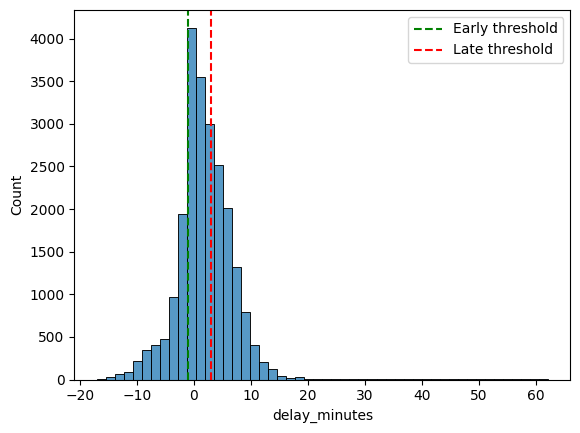

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_low_agree['delay_minutes'], bins=50)
plt.axvline(-1, color='green', linestyle='--', label='Early threshold')
plt.axvline(3, color='red', linestyle='--', label='Late threshold')
plt.legend()
plt.show()

In [20]:
df_low_agree.groupby('rt')[['is_ghost','ghost_frozen','ghost_never_departed']].sum()

,is_ghost,ghost_frozen,ghost_never_departed
rt,,,
169,1,1,0
201,0,0,0
54A,0,0,0


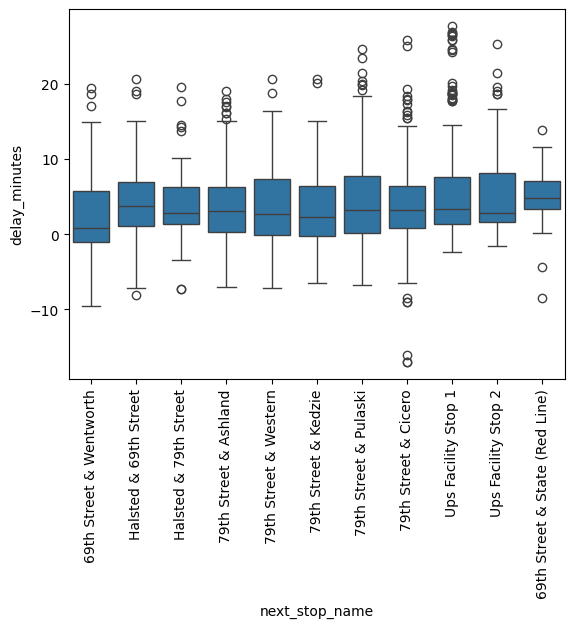

In [21]:
sns.boxplot(x='next_stop_name', y='delay_minutes', data=df_low_agree[df_low_agree['rt']=='169'])
plt.xticks(rotation=90)
plt.show()

In [22]:
df_low_agree[df_low_agree['pdist_unreliable'] == True]['on_time_status'].value_counts()

Series([], Name: count, dtype: int64)

In [25]:
# 1️⃣ Flag whether the row is the first stop of the trip
df['is_first_stop'] = df['scheduled_departure_stop1'] == df['first_stop_name']

# 2️⃣ Flag rows where delay and on_time_status disagree
def status_mismatch(row):
    if row['on_time_status'] == 'early' and row['delay_minutes'] > -1:
        return True
    if row['on_time_status'] == 'on_time' and not (-1 <= row['delay_minutes'] <= 3):
        return True
    if row['on_time_status'] == 'late' and row['delay_minutes'] <= 3:
        return True
    return False

df['mismatch'] = df.apply(status_mismatch, axis=1)

# 3️⃣ Investigate ghost/unreliable matches
df['unreliable'] = df['pdist_unreliable'] | df['is_ghost']

# 4️⃣ Summarize mismatches
summary = df.groupby(['rt', 'is_first_stop', 'unreliable'])['mismatch'].sum()
print(summary)

# 5️⃣ Optional: inspect examples
mismatch_examples = df[df['mismatch']].sort_values('delay_minutes')
print(mismatch_examples[['vid', 'rt', 'first_stop_name', 'delay_minutes',
                         'on_time_status', 'pdist_match_used', 'is_ghost']].head(20))

rt   is_first_stop  unreliable
1    False          False          386
100  False          False          523
                    True             0
103  False          False         2340
                    True             0
                                  ... 
X4   False          True             0
X49  False          False         2457
                    True             0
X9   False          False         2869
                    True             0
Name: mismatch, Length: 226, dtype: int64
          vid   rt               first_stop_name  delay_minutes  \
31       1003    3           State & 95th Street            3.1   
3960623  8627  126     Jackson & Austin Terminal            3.1   
390438   1182   28          Olive-Harvey College            3.1   
390445   1182   28          Olive-Harvey College            3.1   
1670408  4158  151  Union Station Transit Center            3.1   
1670377  4158  151       Clark & Arthur Terminal            3.1   
3960640  8627  126     Jackso

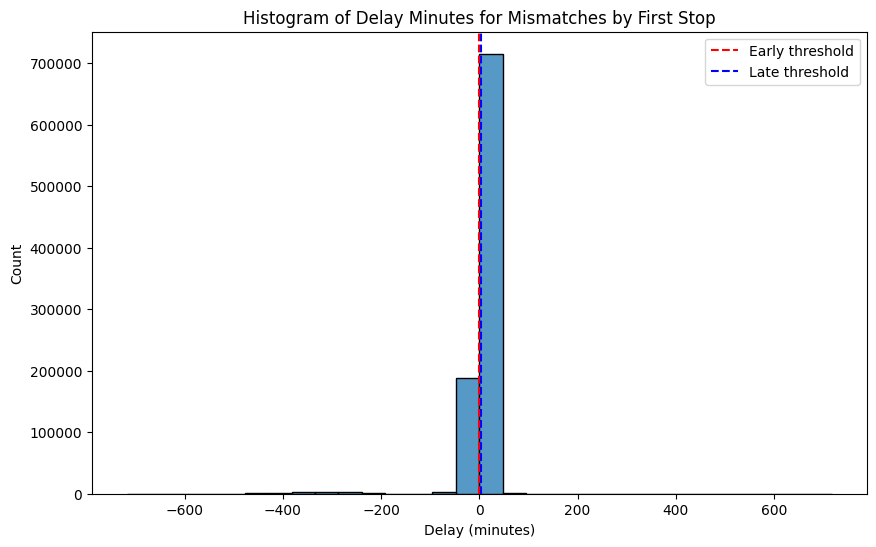

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

EPS = 0.01

def calc_status(delay):
    if delay < -1 - EPS:
        return 'early'
    elif delay > 3 + EPS:
        return 'late'
    else:
        return 'on_time'

# Make sure your dataframe is named df
df['calc_status'] = df['delay_minutes'].apply(calc_status)
mismatches = df[df['calc_status'] != df['on_time_status']]

plt.figure(figsize=(10,6))
sns.histplot(data=mismatches, x='delay_minutes', hue='is_first_stop', multiple='stack', bins=30)
plt.axvline(-1, color='red', linestyle='--', label='Early threshold')
plt.axvline(3, color='blue', linestyle='--', label='Late threshold')
plt.xlabel('Delay (minutes)')
plt.ylabel('Count')
plt.title('Histogram of Delay Minutes for Mismatches by First Stop')
plt.legend()
plt.show()

In [27]:
import pandas as pd

# Make sure your dataframe is sorted by vehicle and timestamp
df_sorted = df.sort_values(['vid', 'tmstmp']).reset_index(drop=True)

# Shift the delay and first stop info by vehicle
df_sorted['prev_delay'] = df_sorted.groupby('vid')['delay_minutes'].shift(1)
df_sorted['prev_trip_end_first_stop'] = df_sorted.groupby('vid')['is_first_stop'].shift(1)

# Flag potential cascading early trips
# Condition: current trip is early, not a first stop, previous delay was positive
df_sorted['cascading_early'] = (
    (df_sorted['on_time_status'] == 'early') &
    (~df_sorted['is_first_stop']) &
    (df_sorted['prev_delay'] > 3)  # threshold for "late enough" to cascade
)

# How many cascading trips we have
print(df_sorted['cascading_early'].sum())

# Optional: inspect them
cascading_examples = df_sorted[df_sorted['cascading_early']]
print(cascading_examples[['vid', 'rt', 'tmstmp', 'delay_minutes', 'on_time_status', 'prev_delay']].head(20))

86423
      vid  rt               tmstmp  delay_minutes on_time_status  prev_delay
124   608  66  2026-02-20 22:07:00           -4.5          early         4.0
164   608  66  2026-02-20 23:11:00           -3.0          early         3.1
189   608  66  2026-02-20 23:54:00           -5.0          early         4.4
212   608  66  2026-02-23 07:45:00           -1.6          early         3.7
294   608  66  2026-02-23 09:56:00           -3.1          early         3.7
792   608  66  2026-02-25 18:02:00           -2.9          early         3.1
794   608  66  2026-02-25 18:05:00           -3.5          early         3.5
797   608  66  2026-02-25 18:10:00           -3.4          early         3.1
880   608  66  2026-02-26 16:46:00           -3.2          early         3.5
932   608  66  2026-02-26 18:09:00           -2.2          early         3.3
975   608  66  2026-02-26 19:20:00           -1.9          early         3.3
1013  608  66  2026-02-26 20:30:00           -2.8          early      

In [1]:
import pandas as pd

df = pd.read_csv("Datasets/api_mar1.csv", dtype=str, nrows=50000)

# Basic stst stats
df["stst"] = pd.to_numeric(df["stst"], errors="coerce")
print(f"stst null rate: {df['stst'].isna().mean()*100:.1f}%")
print(f"stst range: {df['stst'].min():.0f} – {df['stst'].max():.0f} seconds")
print(f"stst in minutes: {df['stst'].min()/60:.1f} – {df['stst'].max()/60:.1f}")
print()

# Convert to minutes and compare against GTFS first stop times
# for a sample of known-good routes
import pandas as pd
trips = pd.read_csv("Datasets/trips.txt", dtype=str)
import re

sample = df[df["pid"].notna() & df["stst"].notna()].head(20)[
    ["vid","rt","pid","stst","tatripid"]
]
sample["stst_min"] = pd.to_numeric(sample["stst"]) / 60
print(sample.to_string())

stst null rate: 0.0%
stst range: 48900 – 73950 seconds
stst in minutes: 815.0 – 1232.5

     vid rt    pid   stst  tatripid  stst_min
0   1095  1   6351  66960       347    1116.0
1   8473  1   6351  65820       346    1097.0
2   7931  1   8085  66360       335    1106.0
3   1082  1   8085  65100       334    1085.0
4   8692  2   5528  66000  88356681    1100.0
5   1268  2   5528  65280  88356681    1088.0
6   1266  2   5528  64500  88356681    1075.0
7   8696  2   5531  65490  88356681    1091.5
8   7990  2   5531  64590  88356681    1076.5
9   8421  2   5531  63690  88356681    1061.5
10  7925  3  18414  67110  88365469    1118.5
11  8675  3  18414  66570  88365468    1109.5
12  7917  3  18414  66030  88365467    1100.5
13  8142  3  18414  65490  88365466    1091.5
14  1287  3  18414  64950  88365465    1082.5
15  7957  3  18414  64380  88365464    1073.0
16  8148  3  18414  63750  88365462    1062.5
17  8345  3  18414  63120  88365461    1052.0
18  8604  3  18414  62460  88365460   

In [2]:
import pandas as pd
import numpy as np

# 1. Confirm cache has shape_id and service_id columns
import pyarrow.parquet as pq
schema = pq.read_schema("gtfs_cache/stop_times_enriched.parquet")
print("Parquet columns:", schema.names)
print()

# 2. Check what first_stop_dep_minutes looks like for a known pid
# pid=6351 → shape should contain "6351"
# trips = pd.read_csv("trips.txt", dtype=str)
import pandas as pd
st = pd.read_parquet("gtfs_cache/stop_times_enriched.parquet")
sample_shape = st[st["shape_id"].str.contains("6351", na=False)].copy()
first_stops = (sample_shape.sort_values("stop_sequence")
               .groupby("trip_id").first().reset_index())
print("First stop dep_minutes for pid=6351 shape:")
print(first_stops[["trip_id","shape_id","departure_minutes"]].head(5))
print()

# 3. Cross-check against vehicle stst values for same pid
vehicles = pd.read_csv("Datasets/api_mar1.csv", dtype=str, nrows=5000)
vehicles["stst_min"] = pd.to_numeric(vehicles["stst"], errors="coerce") / 60.0
print("Vehicle stst_min for pid=6351:")
print(vehicles[vehicles["pid"]=="6351"]["stst_min"].unique()[:5])

Parquet columns: ['trip_id', 'stop_id', 'stop_sequence', 'arrival_minutes', 'departure_minutes', 'shape_dist_traveled', 'stop_name', 'stop_lat', 'stop_lon', 'route_id', 'shape_id', 'service_id', 'direction', 'schd_trip_id']

First stop dep_minutes for pid=6351 shape:
         trip_id  shape_id  departure_minutes
0  6770004362020  67706351              980.5
1  6770007836020  67706351              373.0
2  6770008651020  67706351             1097.0
3  6770009884020  67706351              439.0
4  6770010610020  67706351              455.5

Vehicle stst_min for pid=6351:
[1116. 1097.]


In [3]:
# Quick sanity check — did the stst_index get built with any keys?
# Run this inline before the full analysis
import pandas as pd, numpy as np
import sys
sys.path.insert(0, ".")
from claude_new_test import build_candidate_index, load_gtfs_cache

stop_times, trips_cal = load_gtfs_cache("gtfs_cache")
candidate_index, route_index, pid_to_shapes, stst_index = build_candidate_index(stop_times, trips_cal)

print(f"stst_index size: {len(stst_index):,}")

# Check if our known keys are present
test_cases = [("6351", 1097.0), ("6351", 1116.0), ("8085", 1106.0)]
for pid, stst in test_cases:
    key = (pid, round(stst, 1))
    hit = stst_index.get(key)
    print(f"  ({pid}, {stst}) → {'FOUND: ' + str(hit['trip_id']) if hit else 'MISS'}")

    done (1.7s) — GTFS cache loaded: 2,996,069 stop_times
[3/6] Building vectorized trip index...
    done (6.5s) — 49,936 trips indexed across 131 routes / 782 shapes / 45677 (pid, stst) keys
stst_index size: 45,677
  (6351, 1097.0) → MISS
  (6351, 1116.0) → MISS
  (8085, 1106.0) → MISS


In [11]:
# df = pd.read_csv("Datasets/api_mar1.csv", dtype=str)

chunks = []
for chunk in pd.read_csv("Datasets/api_mar1.csv", 
                            dtype=str,
                            chunksize=500_000):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

unique_pids = df["pid"].dropna().astype(str).unique()
unique_shape_ids = trips["shape_id"].dropna().astype(str).unique()

pid_match_map = {
    pid: any(shape.endswith(pid) for shape in unique_shape_ids)
    for pid in unique_pids
}

In [13]:
any_false = any(not v for v in pid_match_map.values())
print(any_false)

True


In [14]:
num_false = sum(not v for v in pid_match_map.values())
print(num_false)

1


In [15]:
false_pids = [k for k, v in pid_match_map.items() if not v]
print(false_pids[:20])  # show first 20

['28340']


In [16]:
print(f"Total false: {len(false_pids)}")

Total false: 1


In [17]:
from collections import Counter

print(Counter(pid_match_map.values()))

Counter({True: 755, False: 1})


In [39]:
df["pid"].unique()

array(['6351', '8085', '5528', '5531', '18414', '18415', '19378', '19379',
       '19374', '7107', '14134', '4361', '5912', '8959', '9368', '9376',
       '7127', '7131', '582', '9375', '9717', '4658', '8470', '15955',
       '7170', '7171', '4135', '7471', '4275', '4276', '4287', '4288',
       '3916', '3918', '957', '2063', '4096', '4555', '4557', '3932',
       '3936', '6771', '6772', '6778', '6779', '8119', '2162', '2823',
       '6643', '1039', '1042', '8226', '8227', '8228', '8125', '8128',
       '1093', '10916', '10934', '7103', '7104', '5905', '5906', '5907',
       '7174', '7175', '7555', '7556', '8179', '8180', '7014', '7015',
       '6126', '6128', '7805', '1178', '1180', '4107', '4108', '7871',
       '7873', '1151', '1192', '7020', '7021', '4718', '14117', '14120',
       '7456', '7458', '28346', '28350', '4573', '28357', '4588', '4590',
       '1275', '1286', '4726', '4729', '5424', '5425', '4665', '4662',
       '4664', '1970', '1971', '1326', '7023', '7025', '1345', '1

In [40]:
trips['shape_id'].unique()

array(['67707873', '67708470', '67708469', '67719372', '67719373',
       '309000008', '67704276', '67704277', '309000009', '309000010',
       '309000053', '309000001', '309000084', '309000128', '67714118',
       '67729254', '67729257', '67708140', '67705376', '67702946',
       '67703781', '67702944', '67701763', '67704680', '67709371',
       '67703637', '67703639', '67709372', '67709370', '67700582',
       '67707129', '67707131', '67703527', '67713253', '67705678',
       '67705675', '67710943', '67701656', '67728344', '67728314',
       '67701654', '67709376', '67710954', '67709250', '67710949',
       '67707032', '67707030', '67707031', '67707111', '67707110',
       '67707109', '67707108', '67715952', '67710877', '67705687',
       '67712430', '67707112', '67715950', '67708465', '67715951',
       '67714134', '67701328', '67708414', '67701329', '67701970',
       '67708695', '67701277', '67704729', '67701315', '67704587',
       '67704588', '67704586', '67701274', '67728357', 

In [19]:
df.loc[df['pid'] == '28340','rt'].unique()

array(['19'], dtype=object)

In [21]:
import pandas as pd

def check_stst_matches_schedule(api_df, stop_times_df, trips_df, tolerance=0):
    """
    Checks if api stst (seconds past midnight) matches
    scheduled arrival_time for the same route.

    Parameters:
    - api_df: API dataframe (must contain 'stst' and 'rt')
    - stop_times_df: stop_times.txt dataframe
    - trips_df: trips.txt dataframe (must contain 'trip_id' and 'route_id')
    - tolerance: allowed difference in seconds (default 0)

    Returns:
    - api_df with new column 'stst_matches_schedule'
    """

    # 1️⃣ Convert arrival_time to seconds
    stop_times_df = stop_times_df.copy()

    hms = stop_times_df["arrival_time"].str.split(":", expand=True).astype(int)
    stop_times_df["arrival_sec"] = (
        hms[0]*3600 + hms[1]*60 + hms[2]
    )

    # 2️⃣ Merge route_id into stop_times
    stop_times_df = stop_times_df.merge(
        trips_df[["trip_id", "route_id"]],
        on="trip_id",
        how="left"
    )

    # 3️⃣ Build lookup dictionary: route -> set of arrival seconds
    route_schedule_map = (
        stop_times_df
        .groupby("route_id")["arrival_sec"]
        .apply(set)
        .to_dict()
    )

    # 4️⃣ Check match
    def match_row(row):
        route = str(row["rt"])
        stst = int(row["stst"])

        if route not in route_schedule_map:
            return False

        scheduled_times = route_schedule_map[route]

        # exact match
        if tolerance == 0:
            return stst in scheduled_times

        # tolerance match
        return any(abs(stst - t) <= tolerance for t in scheduled_times)

    api_df = api_df.copy()
    api_df["stst_matches_schedule"] = api_df.apply(match_row, axis=1)

    return api_df

In [25]:
stop_times = pd.read_csv('Datasets/stop_times.txt', sep=',', dtype=str)

In [ ]:
df_checked = check_stst_matches_schedule(
    api_df=df,
    stop_times_df=stop_times,
    trips_df=trips,
    tolerance=60  # allow 1 minute difference
)

In [32]:
import pandas as pd

def build_route_schedule_map(stop_times, trips):
    
    # 1️⃣ Keep only needed columns
    st = stop_times[["trip_id", "arrival_time"]].copy()
    
    # 2️⃣ Convert arrival_time to seconds
    hms = st["arrival_time"].str.split(":", expand=True).astype(int)
    st["arrival_sec"] = hms[0]*3600 + hms[1]*60 + hms[2]
    
    # 3️⃣ Group by trip_id (collect arrival times per trip)
    trip_arrivals = (
        st.groupby("trip_id")["arrival_sec"]
        .apply(set)
        .reset_index()
    )
    
    # 4️⃣ Merge into trips to get route_id
    trip_arrivals = trip_arrivals.merge(
        trips[["trip_id", "route_id"]],
        on="trip_id",
        how="left"
    )
    
    # 5️⃣ Group by route_id (collect all arrival times per route)
    route_schedule_map = (
        trip_arrivals
        .explode("arrival_sec")
        .groupby("route_id")["arrival_sec"]
        .apply(set)
        .to_dict()
    )
    
    return route_schedule_map

In [41]:
def check_stst_against_route(api_df, route_schedule_map, tolerance=0):
    
    def matches(route, stst):
        if route not in route_schedule_map:
            return False
        
        scheduled_times = route_schedule_map[route]
        
        if tolerance == 0:
            return stst in scheduled_times
        
        return any(abs(stst - t) <= tolerance for t in scheduled_times)
    
    api_df = api_df.copy()
    api_df["rt"] = api_df["rt"].astype(str)
    api_df["stst"] = api_df["stst"].astype(int)
    
    api_df["stst_matches_schedule"] = [
        matches(route, stst)
        for route, stst in zip(api_df["rt"], api_df["stst"])
    ]
    
    return api_df

In [ ]:
# route_schedule_map = build_route_schedule_map(stop_times, trips)
# print('merge completed')

# df_checked = check_stst_against_route(
#     df,
#     route_schedule_map,
#     tolerance=60  # allow 1 minute slack
# )

In [48]:
import numpy as np
import pandas as pd
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
GTFS_CACHE    = "gtfs_cache"
VEHICLES_PATH = "Datasets/api_mar1.csv"
TOLERANCE     = 60  # seconds; try 0, 30, 60

# ── Build route_schedule_map ──────────────────────────────────────────────────
st = pd.read_parquet(
    Path(GTFS_CACHE) / "stop_times_enriched.parquet",
    columns=["trip_id", "stop_sequence", "departure_minutes", "route_id"]
)
first = (
    st.sort_values("stop_sequence")
    .groupby("trip_id", sort=False)
    .first()
    .reset_index()[["trip_id", "route_id", "departure_minutes"]]
)
first["dep_seconds"] = (first["departure_minutes"] * 60).round().astype(int)

route_schedule_map = (
    first.groupby("route_id")["dep_seconds"]
    .apply(lambda x: np.array(sorted(x.unique()), dtype=np.int32))
    .to_dict()
)
print(f"Built schedule map: {len(route_schedule_map)} routes, "
      f"{sum(len(v) for v in route_schedule_map.values()):,} departure times")

# ── Load vehicles ─────────────────────────────────────────────────────────────
veh = pd.read_csv(VEHICLES_PATH, dtype=str)
veh["rt"]   = veh["rt"].astype(str).str.strip()
veh["stst"] = pd.to_numeric(veh["stst"], errors="coerce").astype("Int64")

# ── Check stst against schedule ───────────────────────────────────────────────
if TOLERANCE == 0:
    match_pairs = {(rt, int(t)) for rt, times in route_schedule_map.items() for t in times}
    veh["stst_matches_schedule"] = [
        (rt, stst) in match_pairs
        for rt, stst in zip(veh["rt"], veh["stst"])
    ]
else:
    def nearest_diff(times, stst):
        if pd.isna(stst):
            return np.inf
        stst = int(stst)
        i = np.searchsorted(times, stst)
        candidates = []
        if i < len(times):  candidates.append(abs(int(times[i])   - stst))
        if i > 0:           candidates.append(abs(int(times[i-1]) - stst))
        return min(candidates) if candidates else np.inf

    veh["stst_matches_schedule"] = [
        nearest_diff(route_schedule_map[rt], stst) <= TOLERANCE
        if rt in route_schedule_map else False
        for rt, stst in zip(veh["rt"], veh["stst"])
    ]

veh["stst_hhmm"] = veh["stst"].apply(
    lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}" if pd.notna(s) else None
)

# ── Summary ───────────────────────────────────────────────────────────────────
total   = len(veh)
matched = veh["stst_matches_schedule"].sum()
print(f"\nstst match rate (tolerance={TOLERANCE}s): {matched:,} / {total:,}  ({matched/total*100:.1f}%)")

route_stats = (
    veh.groupby("rt")["stst_matches_schedule"]
    .agg(n="count", match_pct=lambda x: x.mean() * 100)
    .sort_values("match_pct")
)
print("\nRoutes with lowest stst match rate:")
display(route_stats[route_stats["match_pct"] < 100].head(15))

unmatched = veh[~veh["stst_matches_schedule"]]
if len(unmatched):
    print(f"\nSample unmatched rows ({len(unmatched):,} total):")
    cols = [c for c in ["vid","rt","pid","stst","stst_hhmm","tmstmp"] if c in veh.columns]
    display(unmatched[cols].head(10))

Built schedule map: 131 routes, 42,821 departure times

stst match rate (tolerance=60s): 4,863,303 / 4,994,350  (97.4%)

Routes with lowest stst match rate:


,n,match_pct
rt,,
19,1896,0.000000
N5,5269,39.096603
85,49524,71.508763
11,12305,75.083299
24,18880,78.601695
169,1681,80.487805
52,53764,83.699130
49B,23429,85.475266
62,69255,92.100209



Sample unmatched rows (131,047 total):


,vid,rt,pid,stst,stst_hhmm,tmstmp
238,8932,24,6778,63900,17:45,20260220 18:41
392,8916,52,14120,65820,18:17,20260220 18:41
393,1170,52,14120,65100,18:05,20260220 18:41
394,8104,52,14120,64380,17:53,20260220 18:41
395,8892,52,14120,63690,17:41,20260220 18:41
766,8234,85,7570,66750,18:32,20260220 18:41
768,1271,85,7570,64890,18:01,20260220 18:42
769,1358,85,7570,63930,17:45,20260220 18:41
1015,8932,24,6778,63900,17:45,20260220 18:42
1168,8916,52,14120,65820,18:17,20260220 18:43
